In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('elantra.csv')
df.tail(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
40,10,2012,14512,7.8,257,256.389,231.652
41,10,2013,14876,7.2,223,243.374,233.782
42,11,2010,8631,9.8,161,219.303,219.544
43,11,2011,12414,8.6,255,247.092,227.136
44,11,2012,15923,7.8,246,248.136,231.190
45,11,2013,16751,7.0,231,242.301,234.033
46,12,2010,13096,9.4,170,227.190,220.437
47,12,2011,13025,8.5,253,243.015,227.093
48,12,2012,19024,7.9,275,244.698,231.099
49,12,2013,21692,6.7,279,246.189,234.594


In [3]:
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)
df = df.sort_values(by=['Year', 'Month'], ascending=[True, True])
df = df.reset_index(drop=True)
df.tail(10)

,Month,Year,ElantraSales,Unemployment,Queries,CPI_energy,CPI_all
40,5,2013,25090,7.5,252,240.972,232.124
41,6,2013,22163,7.5,320,245.412,232.860
42,7,2013,23958,7.3,274,245.926,233.252
43,8,2013,24700,7.2,271,244.917,233.433
44,9,2013,19691,7.2,298,245.566,233.743
45,10,2013,14876,7.2,223,243.374,233.782
46,11,2013,16751,7.0,231,242.301,234.033
47,12,2013,21692,6.7,279,246.189,234.594
48,1,2014,15326,6.6,232,247.575,234.933
49,2,2014,16393,6.7,240,246.389,235.169


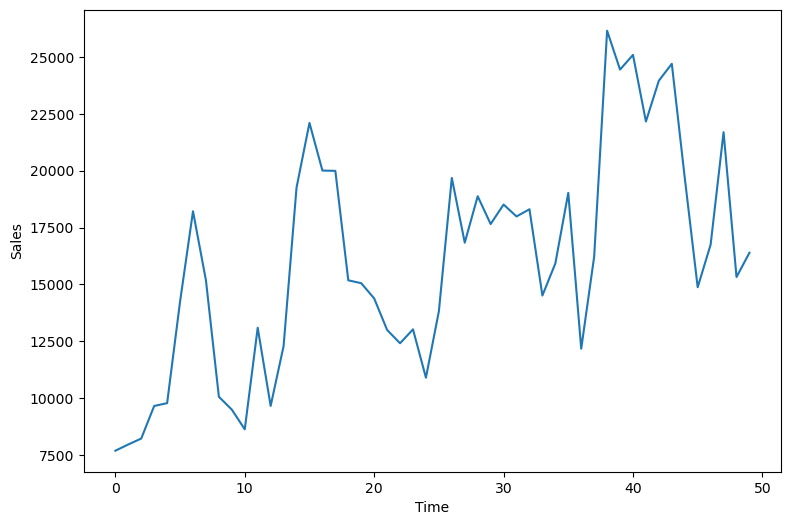

In [4]:
plt.figure(figsize=(9, 6))
plt.plot(df.ElantraSales.values)

plt.xlabel('Time')
plt.ylabel('Sales')

plt.show()

In [5]:
numeric_feats = df.columns.drop(["ElantraSales", "Month", "Year"])
numeric_feats

Index(['Unemployment', 'Queries', 'CPI_energy', 'CPI_all'], dtype='str')

In [6]:
df_train = df[df.Year < 2013]
df_test = df[df.Year >= 2013]

y_train = df_train.ElantraSales.values
y_test = df_test.ElantraSales.values


In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(df_train[numeric_feats])
X_train = scaler.transform(df_train[numeric_feats])
X_test = scaler.transform(df_test[numeric_feats])

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)


In [9]:
def relative_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / np.abs(y_true))
print("Mean Squared Error:", mse)
print("RMSE:", np.sqrt(mse))
print("Relative Error:", relative_error(y_test, y_pred))

Mean Squared Error: 25173777.148995172
RMSE: 5017.347620904413
Relative Error: 0.18959438416755883


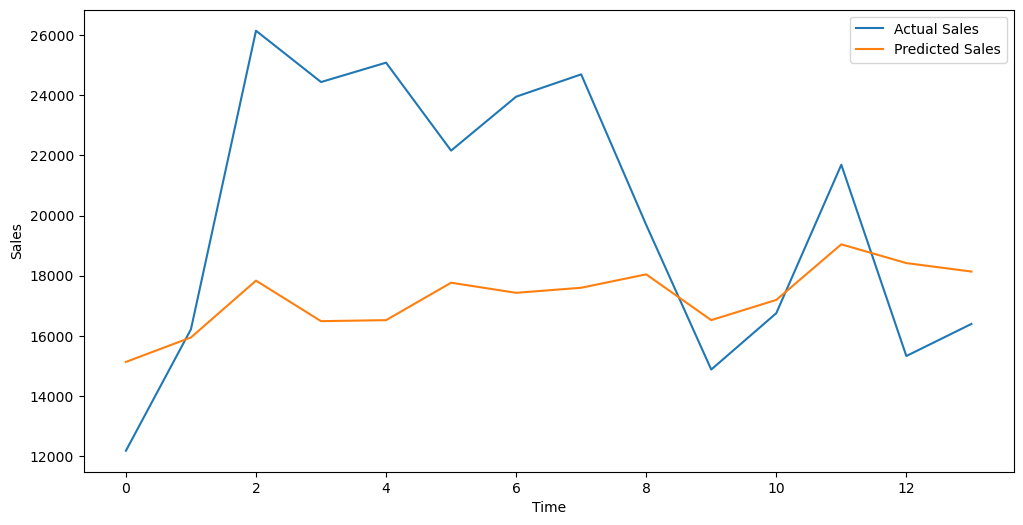

In [10]:

plt.figure(figsize=(12, 6))
plt.plot(y_test)
plt.plot(y_pred)
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend(['Actual Sales', 'Predicted Sales'])
plt.show()

In [11]:
month_one_hot_train = pd.get_dummies(df_train.Month, prefix='Month')
month_one_hot_train.head()

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
0,True,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,True,False,False,False,False,False,False,False


In [12]:
X_train = np.hstack([X_train, month_one_hot_train.values])
X_test  = np.hstack([X_test, pd.get_dummies(df_test.Month, prefix='Month').values])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("RMSE:", np.sqrt(mse))
print("Relative Error:", relative_error(y_test, y_pred))

Mean Squared Error: 12890766.360212313
RMSE: 3590.371340155822
Relative Error: 0.12782187866064212


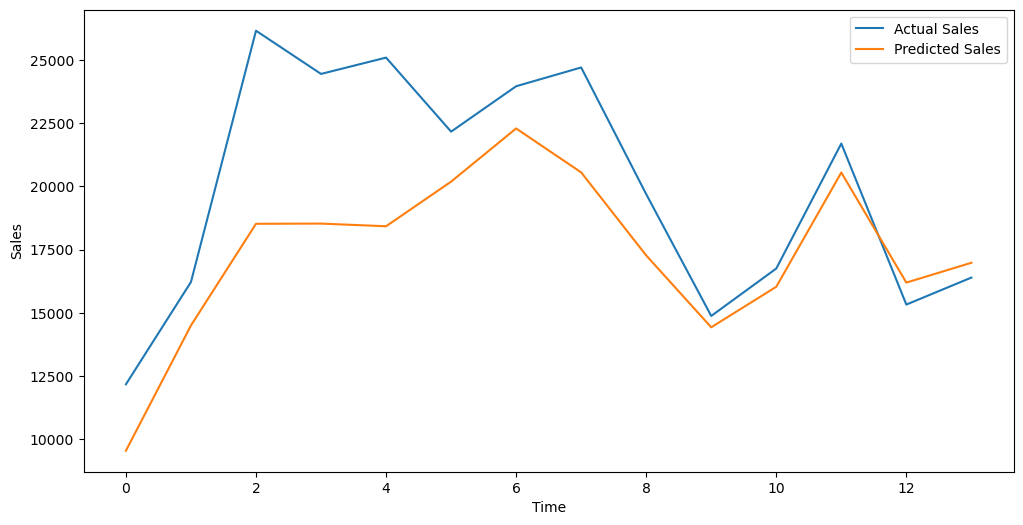

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(y_test)
plt.plot(y_pred)
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend(['Actual Sales', 'Predicted Sales'])
plt.show()